# Chapter 2: Supervised Learning
### *Introduction to Machine Learning with Python* — Müller & Guido

---

## 📌 Chapter Summary

This is the core chapter of the book, covering the most widely used supervised learning algorithms. Each algorithm is explained theoretically, implemented using scikit-learn, and evaluated on real datasets.

### Algorithms Covered:
| # | Algorithm | Task |
|---|---|---|
| 1 | k-Nearest Neighbors (k-NN) | Classification & Regression |
| 2 | Linear Models (Ridge, Lasso, Logistic, LinearSVC) | Classification & Regression |
| 3 | Naive Bayes | Classification |
| 4 | Decision Trees | Classification & Regression |
| 5 | Random Forests | Classification & Regression |
| 6 | Gradient Boosting | Classification & Regression |
| 7 | Support Vector Machines (SVM) | Classification & Regression |
| 8 | Neural Networks (MLPClassifier) | Classification & Regression |

---

## 2.1 Classification vs Regression

### Theory

**Supervised learning** predicts an output from labeled input-output pairs.

| Task | Output Type | Example |
|---|---|---|
| **Classification** | Discrete category | "Is this email spam?" |
| **Regression** | Continuous number | "What will house prices be?" |

Binary classification: 2 classes (yes/no). Multiclass: 3+ classes.

The key question to distinguish: *Is there continuity in the output?* If yes → regression. If no → classification.

## 2.2 Generalization, Overfitting, and Underfitting

### Theory — The Fundamental Tension in ML

- **Generalization**: The ability of a model to perform well on *new, unseen* data
- **Overfitting**: Model is too complex → memorizes training data, fails on test data
- **Underfitting**: Model is too simple → fails to capture patterns in training data

The **bias-variance tradeoff**:
- High complexity → low bias (fits training well), high variance (unstable on new data) → **overfitting**
- Low complexity → high bias (doesn't fit well), low variance (stable) → **underfitting**

The sweet spot is the right **model complexity** for your dataset size.

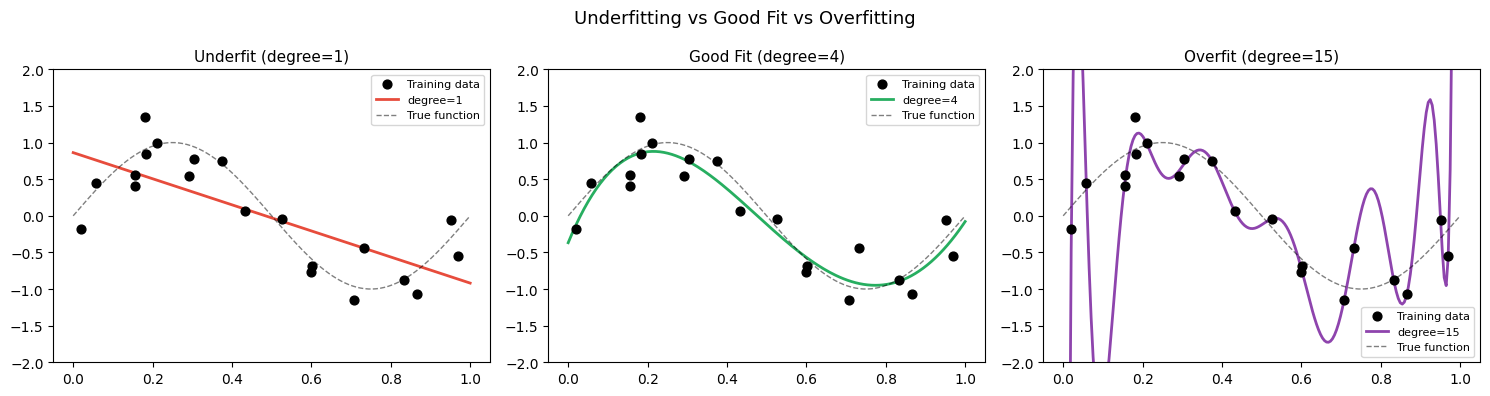

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Demonstrate overfitting vs underfitting with polynomial regression
np.random.seed(42)
X_raw = np.sort(np.random.uniform(0, 1, 20))
y_raw = np.sin(2 * np.pi * X_raw) + np.random.normal(0, 0.3, 20)
X_plot = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Underfitting vs Good Fit vs Overfitting", fontsize=13)
titles = ['Underfit (degree=1)', 'Good Fit (degree=4)', 'Overfit (degree=15)']
degrees = [1, 4, 15]
colors = ['#E74C3C', '#27AE60', '#8E44AD']

for ax, deg, title, color in zip(axes, degrees, titles, colors):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=deg)),
        ('lin',  LinearRegression())
    ])
    model.fit(X_raw.reshape(-1,1), y_raw)
    y_fit = model.predict(X_plot.reshape(-1,1))
    
    ax.scatter(X_raw, y_raw, color='k', s=40, zorder=3, label='Training data')
    ax.plot(X_plot, y_fit, color=color, lw=2, label=f'degree={deg}')
    ax.plot(X_plot, np.sin(2*np.pi*X_plot), 'k--', lw=1, alpha=0.5, label='True function')
    ax.set_ylim(-2, 2)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 2.3 k-Nearest Neighbors (k-NN)

### Theory

k-NN is a **non-parametric** algorithm — it makes no assumptions about data distribution. It stores all training data and classifies new points by finding their **k nearest neighbors** and taking a majority vote (classification) or average (regression).

**Key hyperparameter:** `n_neighbors` (k)
- Small k → complex model (overfitting risk)
- Large k → simple model (underfitting risk)

**When to use:** Small datasets, interpretability matters, need a quick baseline  
**When NOT to use:** Large datasets (slow prediction), many features (curse of dimensionality)

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Breast Cancer dataset: classify tumors as malignant/benign
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=66
)

print("Dataset:", cancer.DESCR.split('\n')[0])
print(f"Samples: {cancer.data.shape[0]}, Features: {cancer.data.shape[1]}")
print(f"Classes: {cancer.target_names}")

Dataset: .. _breast_cancer_dataset:
Samples: 569, Features: 30
Classes: ['malignant' 'benign']


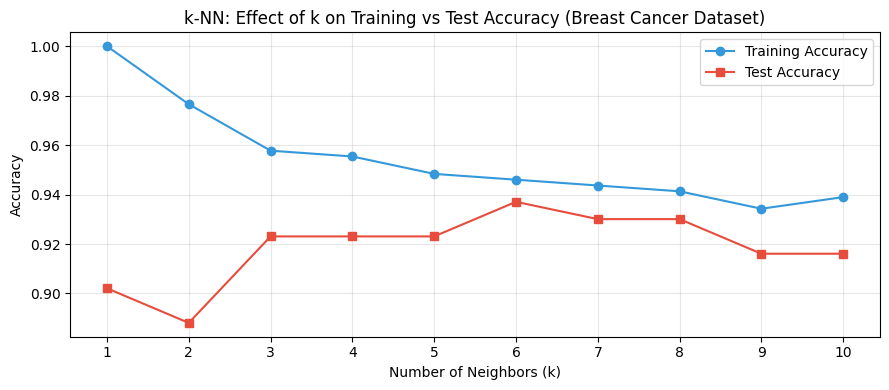

Best k: 6 with test accuracy 0.9371


In [3]:
# Test different k values to find the optimal one
train_accuracy = []
test_accuracy  = []

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracy.append(knn.score(X_train, y_train))
    test_accuracy.append(knn.score(X_test, y_test))

plt.figure(figsize=(9, 4))
plt.plot(range(1,11), train_accuracy, '-o', color='#3498DB', label='Training Accuracy')
plt.plot(range(1,11), test_accuracy,  '-s', color='#E74C3C', label='Test Accuracy')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("k-NN: Effect of k on Training vs Test Accuracy (Breast Cancer Dataset)")
plt.xticks(range(1,11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = test_accuracy.index(max(test_accuracy)) + 1
print(f"Best k: {best_k} with test accuracy {max(test_accuracy):.4f}")

---
## 2.4 Linear Models

### Theory

Linear models make predictions using a **linear combination of features**:

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_n x_n = \mathbf{w} \cdot \mathbf{x} + b$$

Where:
- $w$ = weights (learned from data)
- $b$ = bias/intercept
- $x$ = input features

Different linear models differ in **how they penalize large weights** (regularization):

| Model | Regularization | Penalty | Effect |
|---|---|---|---|
| **LinearRegression** | None | — | Can overfit on many features |
| **Ridge** | L2 | $\lambda \sum w_i^2$ | Shrinks all weights, keeps all features |
| **Lasso** | L1 | $\lambda \sum |w_i|$ | Sets some weights to exactly 0 (sparse) |
| **LogisticRegression** | L2 | (for classification) | — |

In [4]:
# Linear Regression for Regression
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
import numpy as np

diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, random_state=42
)

# Compare models
models = {
    'LinearRegression': LinearRegression(),
    'Ridge (alpha=1)':  Ridge(alpha=1),
    'Ridge (alpha=10)': Ridge(alpha=10),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, max_iter=10000),
}

print(f"{'Model':<25} {'Train R²':>10} {'Test R²':>10} {'Non-zero coefs':>14}")
print("-" * 62)

for name, model in models.items():
    model.fit(X_train, y_train)
    tr = model.score(X_train, y_train)
    te = model.score(X_test, y_test)
    nz = np.sum(model.coef_ != 0)
    print(f"{name:<25} {tr:>10.4f} {te:>10.4f} {nz:>14}")

Model                       Train R²    Test R² Non-zero coefs
--------------------------------------------------------------
LinearRegression              0.5190     0.4849             10
Ridge (alpha=1)               0.4273     0.4384             10
Ridge (alpha=10)              0.1508     0.1564             10
Lasso (alpha=0.1)             0.5078     0.5020              7


In [5]:
# Logistic Regression for Classification
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=42
)

# C = inverse regularization strength (higher C = less regularization)
for C in [0.001, 0.1, 1, 10, 100]:
    lr = LogisticRegression(C=C, max_iter=10000)
    lr.fit(X_train, y_train)
    print(f"C={C:<6}  Train: {lr.score(X_train, y_train):.4f}  Test: {lr.score(X_test, y_test):.4f}")

C=0.001   Train: 0.9366  Test: 0.9790
C=0.1     Train: 0.9437  Test: 0.9650
C=1       Train: 0.9624  Test: 0.9650
C=10      Train: 0.9765  Test: 0.9650
C=100     Train: 0.9812  Test: 0.9650


### Key Insight: Regularization Parameter

- **Ridge/Lasso:** `alpha` — *higher alpha = more regularization = simpler model*
- **LogisticRegression:** `C` — *higher C = less regularization = more complex model*

Both control the bias-variance tradeoff. Tune using cross-validation!

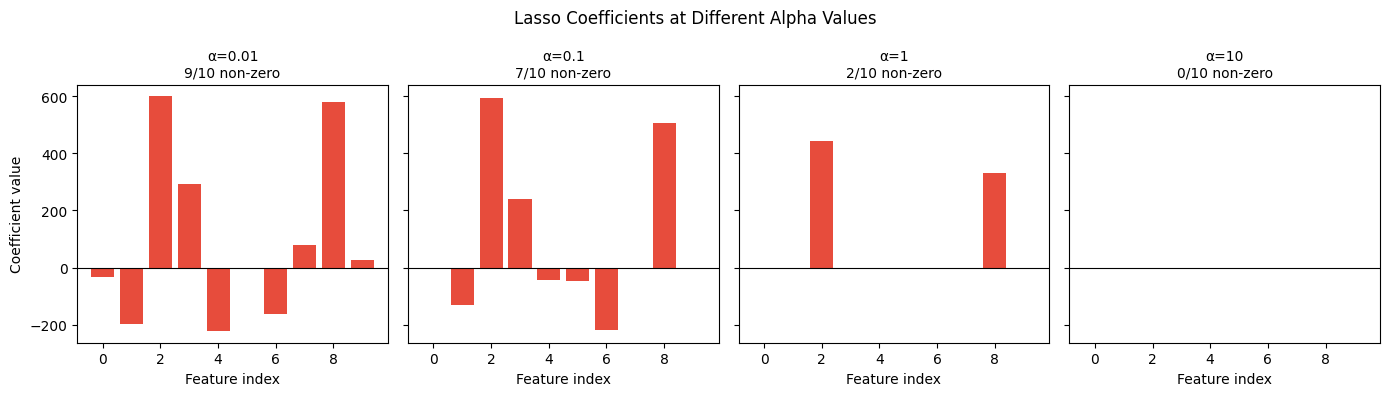

In [6]:
# Visualize Lasso sparsity effect
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, random_state=0)

alphas = [0.01, 0.1, 1, 10]
fig, axes = plt.subplots(1, len(alphas), figsize=(14, 4), sharey=True)
fig.suptitle("Lasso Coefficients at Different Alpha Values", fontsize=12)

for ax, alpha in zip(axes, alphas):
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    nonzero = np.sum(lasso.coef_ != 0)
    colors = ['#E74C3C' if c != 0 else '#BDC3C7' for c in lasso.coef_]
    ax.bar(range(len(lasso.coef_)), lasso.coef_, color=colors)
    ax.set_title(f"α={alpha}\n{nonzero}/{len(lasso.coef_)} non-zero", fontsize=10)
    ax.set_xlabel("Feature index")
    ax.axhline(0, color='k', lw=0.8)

axes[0].set_ylabel("Coefficient value")
plt.tight_layout()
plt.show()

---
## 2.5 Naive Bayes Classifiers

### Theory

Naive Bayes applies **Bayes' Theorem** with the "naive" assumption that all features are **conditionally independent** given the class label:

$$P(y | x_1, \ldots, x_n) \propto P(y) \prod_{i=1}^{n} P(x_i | y)$$

Variants:
- **GaussianNB**: Assumes features follow a Gaussian (normal) distribution → for continuous data
- **MultinomialNB**: For discrete count data (e.g., word counts in text)
- **BernoulliNB**: For binary features (e.g., word presence/absence)

**Pros:** Extremely fast, works well on text, requires little data  
**Cons:** The independence assumption is often wrong in practice

In [7]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split

# GaussianNB on continuous data
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0
)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
print("GaussianNB — Breast Cancer Dataset")
print(f"  Training accuracy: {gnb.score(X_train, y_train):.4f}")
print(f"  Test accuracy:     {gnb.score(X_test, y_test):.4f}")

# Class probabilities for a single sample
probs = gnb.predict_proba(X_test[:1])
print(f"\n  P(malignant) for sample 0: {probs[0][0]:.4f}")
print(f"  P(benign)    for sample 0: {probs[0][1]:.4f}")

GaussianNB — Breast Cancer Dataset
  Training accuracy: 0.9507
  Test accuracy:     0.9371

  P(malignant) for sample 0: 1.0000
  P(benign)    for sample 0: 0.0000


---
## 2.6 Decision Trees

### Theory

A decision tree learns a hierarchy of **if/else questions** about features. Each internal node tests a feature, each leaf contains a prediction.

**Splitting criterion:**
- Classification: **Gini impurity** or **Entropy (Information Gain)**
- Regression: **Mean Squared Error (MSE)**

$$\text{Gini impurity} = 1 - \sum_{k} p_k^2$$

The algorithm greedily chooses the split that **maximally reduces impurity**.

**Key hyperparameters:**
- `max_depth`: Limits tree depth → prevents overfitting
- `min_samples_split`: Minimum samples required to split a node

**Pros:** Interpretable, handles mixed feature types, no scaling needed  
**Cons:** Prone to overfitting without depth limits

In [8]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=42
)

# Compare trees with different max_depth
print(f"{'max_depth':<12} {'Train Acc':>10} {'Test Acc':>10} {'n_leaves':>10}")
print("-" * 44)

for depth in [1, 2, 3, 4, 5, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0)
    tree.fit(X_train, y_train)
    tr = tree.score(X_train, y_train)
    te = tree.score(X_test, y_test)
    nl = tree.get_n_leaves()
    depth_str = str(depth) if depth is not None else 'None (full)'
    print(f"{depth_str:<12} {tr:>10.4f} {te:>10.4f} {nl:>10}")

max_depth     Train Acc   Test Acc   n_leaves
--------------------------------------------
1                0.9225     0.8951          2
2                0.9460     0.9161          4
3                0.9718     0.9580          8
4                0.9953     0.9510         12
5                0.9953     0.9580         13
None (full)      1.0000     0.9301         16


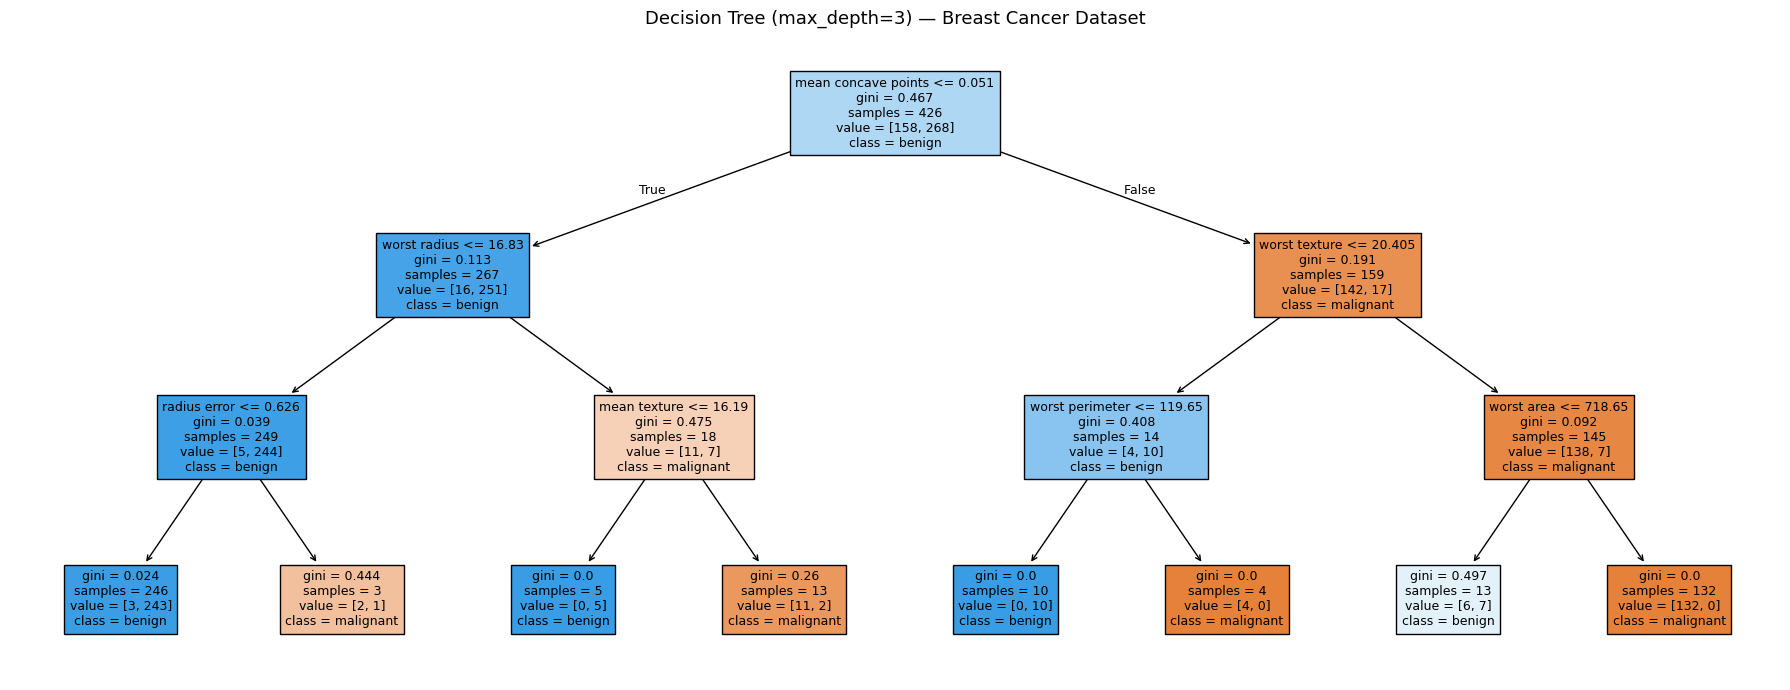

In [9]:
# Visualize the tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_viz = DecisionTreeClassifier(max_depth=3, random_state=0)
tree_viz.fit(X_train, y_train)

plt.figure(figsize=(18, 7))
plot_tree(tree_viz,
          feature_names=cancer.feature_names,
          class_names=cancer.target_names,
          filled=True, impurity=True, fontsize=9)
plt.title("Decision Tree (max_depth=3) — Breast Cancer Dataset", fontsize=13)
plt.tight_layout()
plt.show()

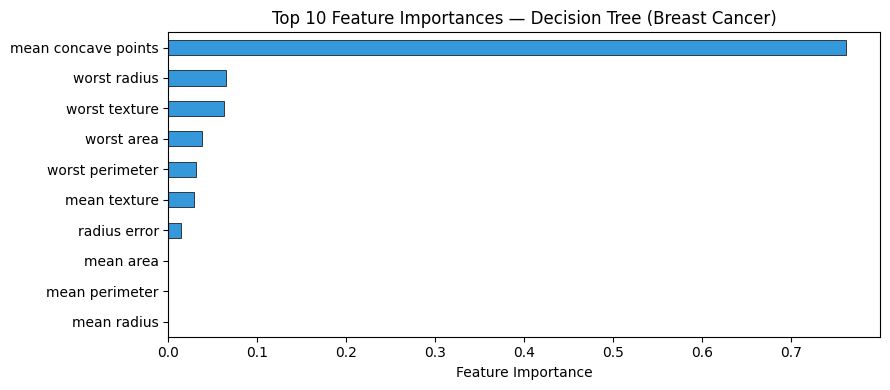

In [10]:
# Feature importance from a decision tree
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(tree_viz.feature_importances_, index=cancer.feature_names)
top10 = importances.nlargest(10)

plt.figure(figsize=(9, 4))
top10.sort_values().plot(kind='barh', color='#3498DB', edgecolor='k', linewidth=0.5)
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances — Decision Tree (Breast Cancer)")
plt.tight_layout()
plt.show()

---
## 2.7 Ensembles: Random Forests

### Theory

A **Random Forest** is an ensemble of many decision trees, each trained on a **random subset** of data (bootstrap sampling) and a **random subset of features** at each split.

Final prediction = **majority vote** (classification) or **average** (regression) of all trees.

**Why does this work?** Each tree makes different errors due to randomness. Averaging their predictions **cancels out errors** — this is called **variance reduction**.

$$\hat{y}_{\text{RF}} = \frac{1}{T} \sum_{t=1}^{T} \hat{y}_t$$

**Key hyperparameters:**
- `n_estimators`: Number of trees (more = better, but slower)
- `max_features`: Features considered at each split (√n_features for classification)
- `max_depth`: Controls individual tree complexity

**Pros:** Excellent performance, robust to overfitting, handles large datasets  
**Cons:** Less interpretable, slower than single trees

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0
)

# Single tree vs Random Forest comparison
from sklearn.tree import DecisionTreeClassifier

dt  = DecisionTreeClassifier(random_state=0)
rf  = RandomForestClassifier(n_estimators=100, random_state=0)

for name, model in [('Decision Tree', dt), ('Random Forest (100 trees)', rf)]:
    model.fit(X_train, y_train)
    print(f"{name}:")
    print(f"  Train: {model.score(X_train, y_train):.4f}  |  Test: {model.score(X_test, y_test):.4f}")

Decision Tree:
  Train: 1.0000  |  Test: 0.8811
Random Forest (100 trees):
  Train: 1.0000  |  Test: 0.9720


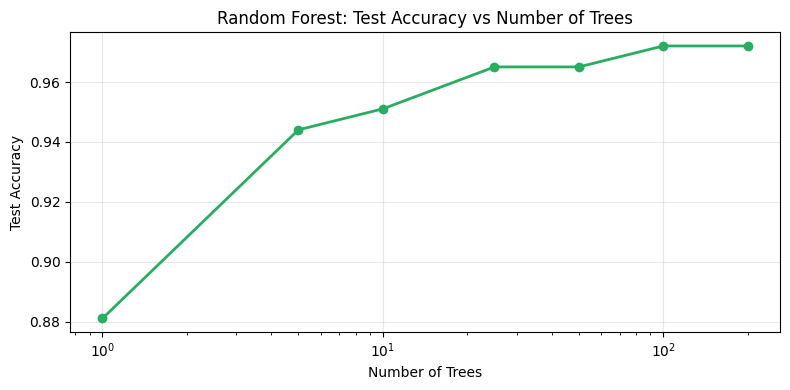

In [12]:
# Effect of number of trees
import numpy as np

n_trees = [1, 5, 10, 25, 50, 100, 200]
test_scores = []

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=0)
    rf.fit(X_train, y_train)
    test_scores.append(rf.score(X_test, y_test))

plt.figure(figsize=(8, 4))
plt.plot(n_trees, test_scores, '-o', color='#27AE60', lw=2)
plt.xscale('log')
plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")
plt.title("Random Forest: Test Accuracy vs Number of Trees")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2.8 Gradient Boosting

### Theory

**Gradient Boosting** trains trees **sequentially**, where each new tree corrects the errors of the previous ones. Unlike Random Forests (parallel, independent trees), Gradient Boosting builds trees **one at a time**.

**Algorithm:**
1. Start with a simple initial prediction (e.g., mean value)
2. Compute the **residuals** (prediction errors)
3. Fit a new tree to predict the residuals
4. Add this tree to the ensemble with a small weight (`learning_rate`)
5. Repeat for `n_estimators` steps

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

**Key hyperparameters:**
- `n_estimators`: More trees = more complex (can overfit!)
- `learning_rate`: Step size — must balance with n_estimators
- `max_depth`: Typically 1-5 for gradient boosting

**Pros:** Often the best off-the-shelf performance  
**Cons:** Many hyperparameters, slow to train, sensitive to outliers

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0
)

# Default settings
gbm = GradientBoostingClassifier(random_state=0)
gbm.fit(X_train, y_train)
print("Default GBM:")
print(f"  Train: {gbm.score(X_train, y_train):.4f}  |  Test: {gbm.score(X_test, y_test):.4f}")

# Tuned settings
gbm_tuned = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                        max_depth=3, random_state=0)
gbm_tuned.fit(X_train, y_train)
print("\nTuned GBM (n_estimators=200, lr=0.05):")
print(f"  Train: {gbm_tuned.score(X_train, y_train):.4f}  |  Test: {gbm_tuned.score(X_test, y_test):.4f}")

Default GBM:
  Train: 1.0000  |  Test: 0.9650

Tuned GBM (n_estimators=200, lr=0.05):
  Train: 1.0000  |  Test: 0.9580


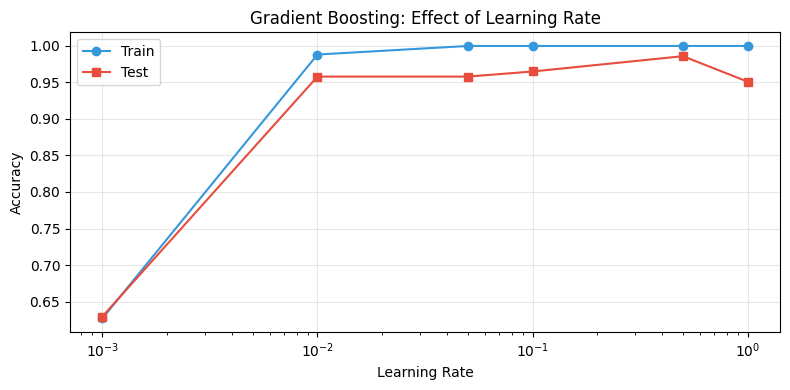

In [14]:
# Compare Random Forest vs Gradient Boosting with learning rate effect
import matplotlib.pyplot as plt

lr_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
train_scores, test_scores = [], []

for lr in lr_values:
    gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, random_state=0)
    gbm.fit(X_train, y_train)
    train_scores.append(gbm.score(X_train, y_train))
    test_scores.append(gbm.score(X_test, y_test))

plt.figure(figsize=(8, 4))
plt.plot(lr_values, train_scores, '-o', label='Train', color='#3498DB')
plt.plot(lr_values, test_scores,  '-s', label='Test',  color='#E74C3C')
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting: Effect of Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2.9 Support Vector Machines (SVM)

### Theory

SVMs find the **decision boundary that maximizes the margin** between classes — the hyperplane with the largest distance to the nearest training points (called **support vectors**).

**The kernel trick** allows SVMs to work in high-dimensional (even infinite-dimensional) feature spaces without explicitly computing the transformation:

$$K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)$$

Common kernels:
- **Linear**: $K(x, y) = x \cdot y$
- **RBF (Gaussian)**: $K(x, y) = \exp(-\gamma ||x - y||^2)$
- **Polynomial**: $K(x, y) = (x \cdot y + c)^d$

**Key hyperparameters:**
- `C`: Regularization — high C = complex boundary, low C = simpler
- `gamma`: RBF kernel width — high = complex boundary (overfitting risk)

> **Important:** SVMs are very sensitive to feature scale — always normalize data first!

In [15]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0
)

# Without scaling
svm_raw = SVC(kernel='rbf', C=1, random_state=42)
svm_raw.fit(X_train, y_train)
print("SVM without scaling:")
print(f"  Train: {svm_raw.score(X_train, y_train):.4f}  Test: {svm_raw.score(X_test, y_test):.4f}")

# With scaling — the right approach!
svm_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma=0.1))
])
svm_scaled.fit(X_train, y_train)
print("\nSVM WITH StandardScaler:")
print(f"  Train: {svm_scaled.score(X_train, y_train):.4f}  Test: {svm_scaled.score(X_test, y_test):.4f}")

SVM without scaling:
  Train: 0.9038  Test: 0.9371

SVM WITH StandardScaler:
  Train: 1.0000  Test: 0.9650


---
## 2.10 Neural Networks (MLPClassifier)

### Theory

A **Multilayer Perceptron (MLP)** consists of layers of neurons:

1. **Input layer**: One neuron per feature
2. **Hidden layers**: Transform representations through nonlinear activations
3. **Output layer**: One neuron per class (classification)

Each neuron computes:
$$h = \text{activation}\left(\sum_i w_i x_i + b\right)$$

**Activation functions:**
- **ReLU** (default): $f(x) = \max(0, x)$ — most common, fast
- **Tanh**: $f(x) = \tanh(x)$ — range (-1, 1)
- **Sigmoid**: $f(x) = 1/(1+e^{-x})$ — range (0, 1)

Training uses **backpropagation** — computing gradients through the chain rule to adjust weights with **gradient descent**.


In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0
)

# Scale the data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Compare architectures
architectures = {
    'Small (1x100)':   (100,),
    'Medium (2x100)':  (100, 100),
    'Large (3x100)':   (100, 100, 100),
}

print(f"{'Architecture':<20} {'Train':>8} {'Test':>8}")
print("-" * 38)
for name, layers in architectures.items():
    mlp = MLPClassifier(hidden_layer_sizes=layers, max_iter=1000, random_state=0)
    mlp.fit(X_train_sc, y_train)
    print(f"{name:<20} {mlp.score(X_train_sc, y_train):>8.4f} {mlp.score(X_test_sc, y_test):>8.4f}")

Architecture            Train     Test
--------------------------------------
Small (1x100)          1.0000   0.9720
Medium (2x100)         1.0000   0.9650
Large (3x100)          1.0000   0.9650


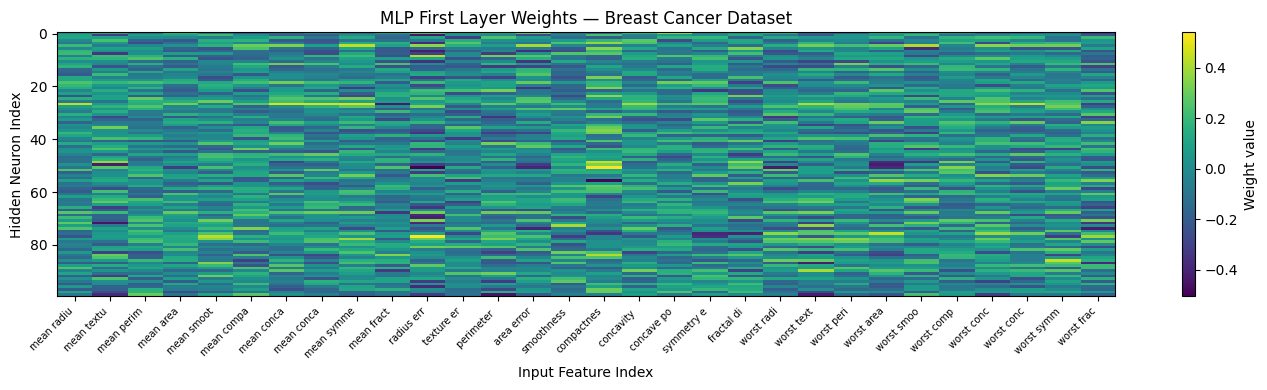

In [17]:
# Visualize learned weights of first layer (heatmap)
import matplotlib.pyplot as plt
import numpy as np

mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=0)
mlp.fit(X_train_sc, y_train)

# Plot weights connecting input features to first hidden layer neurons
weights = mlp.coefs_[0]  # shape: (n_features, n_hidden)

plt.figure(figsize=(14, 4))
plt.imshow(weights.T, interpolation='nearest', cmap='viridis', aspect='auto')
plt.colorbar(label='Weight value')
plt.xlabel('Input Feature Index')
plt.ylabel('Hidden Neuron Index')
plt.title('MLP First Layer Weights — Breast Cancer Dataset')
plt.xticks(range(len(cancer.feature_names)),
           [f[:10] for f in cancer.feature_names], rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

---
## 2.11 Model Uncertainty: predict_proba

### Theory

Many classifiers can output **probability estimates** — not just a class, but *how confident* the model is:

- `predict()`: Returns the predicted class label
- `predict_proba()`: Returns probability for each class (sums to 1)
- `decision_function()`: Returns raw score (not probability)

In [18]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0
)

gbm = GradientBoostingClassifier(random_state=0)
gbm.fit(X_train, y_train)

# Show probabilities for first 5 test samples
proba = gbm.predict_proba(X_test[:5])
print("Probability estimates for first 5 test samples:")
print(f"{'':5} {'setosa':>10} {'versicolor':>12} {'virginica':>11}  {'Predicted':>10}")
print("-" * 55)
for i, (row, pred) in enumerate(zip(proba, gbm.predict(X_test[:5]))):
    print(f"#{i:<4} {row[0]:>10.4f} {row[1]:>12.4f} {row[2]:>11.4f}  {iris.target_names[pred]:>10}")

Probability estimates for first 5 test samples:
          setosa   versicolor   virginica   Predicted
-------------------------------------------------------
#0        0.0000       0.0000      1.0000   virginica
#1        0.0000       1.0000      0.0000  versicolor
#2        1.0000       0.0000      0.0000      setosa
#3        0.0000       0.0000      1.0000   virginica
#4        1.0000       0.0000      0.0000      setosa


---
## 2.12 Comparing All Algorithms — Summary

Let's run all algorithms on the same dataset for a fair comparison.

In [19]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import pandas as pd
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

algorithms = [
    ('k-NN (k=5)',            KNeighborsClassifier(5),                      True),
    ('Logistic Regression',   LogisticRegression(max_iter=5000),             True),
    ('Gaussian Naive Bayes',  GaussianNB(),                                  False),
    ('Decision Tree',         DecisionTreeClassifier(max_depth=4, random_state=0), False),
    ('Random Forest',         RandomForestClassifier(100, random_state=0),  False),
    ('Gradient Boosting',     GradientBoostingClassifier(random_state=0),   False),
    ('SVM (RBF)',             SVC(kernel='rbf', C=10, gamma=0.1),           True),
    ('Neural Network',        MLPClassifier(max_iter=2000, random_state=0), True),
]

results = []
for name, model, use_scaled in algorithms:
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test
    model.fit(Xtr, y_train)
    results.append({'Algorithm': name,
                    'Train Acc': model.score(Xtr, y_train),
                    'Test Acc':  model.score(Xte, y_test),
                    'Scaled':   '✓' if use_scaled else ''})

df = pd.DataFrame(results).sort_values('Test Acc', ascending=False)
print(df.to_string(index=False))

           Algorithm  Train Acc  Test Acc Scaled
 Logistic Regression   0.985915  0.979021      ✓
       Random Forest   1.000000  0.972028       
      Neural Network   0.997653  0.972028      ✓
          k-NN (k=5)   0.978873  0.958042      ✓
   Gradient Boosting   1.000000  0.958042       
Gaussian Naive Bayes   0.936620  0.958042       
           SVM (RBF)   1.000000  0.958042      ✓
       Decision Tree   0.995305  0.951049       


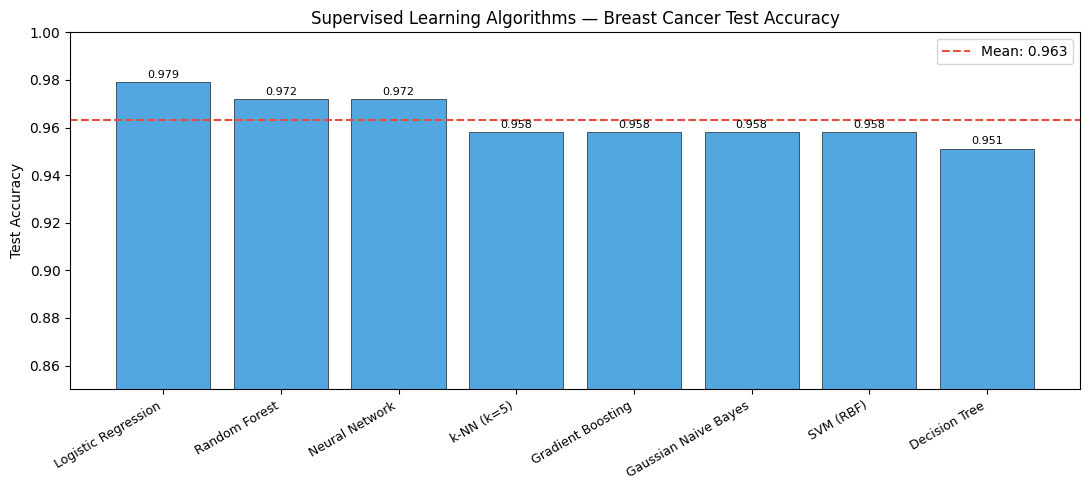

In [20]:
# Visual comparison
import matplotlib.pyplot as plt

x = range(len(df))
plt.figure(figsize=(11, 5))
bars = plt.bar(x, df['Test Acc'], color='#3498DB', edgecolor='k', lw=0.5, alpha=0.85)
plt.xticks(x, df['Algorithm'], rotation=30, ha='right', fontsize=9)
plt.ylabel('Test Accuracy')
plt.title('Supervised Learning Algorithms — Breast Cancer Test Accuracy')
plt.ylim(0.85, 1.0)
plt.axhline(df['Test Acc'].mean(), color='#E74C3C', ls='--', lw=1.5, label=f"Mean: {df['Test Acc'].mean():.3f}")
plt.legend()
for bar, val in zip(bars, df['Test Acc']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

---
## 📝 Chapter 2 Summary

| Algorithm | Strengths | Weaknesses | Needs Scaling? |
|---|---|---|---|
| **k-NN** | Simple, no training | Slow prediction, curse of dimensionality | ✓ |
| **Linear Models** | Fast, interpretable, regularization | Assumes linearity | ✓ |
| **Naive Bayes** | Very fast, works with text | Assumes feature independence | ✗ |
| **Decision Trees** | Interpretable, no scaling | Prone to overfitting | ✗ |
| **Random Forest** | Robust, great baseline | Less interpretable | ✗ |
| **Gradient Boosting** | Often best accuracy | Many hyperparameters, slow | ✗ |
| **SVM** | Great in high-dim space | Sensitive to scale & params | ✓ |
| **Neural Networks** | Very flexible | Black box, needs much data & tuning | ✓ |

> 📌 **Rule of thumb:** Start simple (Linear/Naive Bayes/Random Forest). Move to more complex models only if needed.
